## Phase 1.1 - Accessing Semantic Scholar and Handling IPs/API keys 

In [2]:
import os
import sys
from dotenv import load_dotenv
import requests
from semanticscholar import AsyncSemanticScholar
import asyncio
import nest_asyncio
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
nest_asyncio.apply()

load_dotenv(override=True)


# 1. GETTING USER API KEY. DEFAULTS AND CHECKS IP IF KEY IS NOT FOUND
api_key = os.getenv("SEMANTIC_SCHOLAR_API_KEY")
is_key_good = False

print("Searching for User's API Key...")

if api_key is None or api_key == "your_key_here" or api_key.strip() == "":
    print(f"User provided this: '{api_key}' as an API Key. Defaulting to lower limit access...")
    print("Checking IP status...")

    #CHECKING IF IP IS BLOCKED OR NOT
    url = "https://api.semanticscholar.org/graph/v1/paper/search"
    query_params = {"query": "test", "limit": 1}
    
    print("Pinging Semantic Scholar...")
    response = requests.get(url, params=query_params)

    if response.status_code == 200:
        print("Your IP is clear to access Semantic Scholar. Ready to start!")
    elif response.status_code == 429:
        sys.exit("Your IP is currently blocked from using Semantic Scholar")

else:
    print("API Key found! Going to Semantic Scholar...")
    is_key_good = True

Searching for User's API Key...
API Key found! Going to Semantic Scholar...


In [4]:

# 2. CONNECTING TO SEMANTIC SCHOLAR
sch = None
if is_key_good:
    sch = AsyncSemanticScholar(api_key=api_key)
else:
    sch = AsyncSemanticScholar()


# 3. VALIDATING THE API KEY
try:
    testing_api_key_works = await sch.get_paper("8ceb75144ecb846bf463e7565e6a18998ae29d1a", fields=["title"])
    # The id for Protein measurement with the Folin phenol reagent. That is the most cited paper on Semantic Scholar.
    print("Your API Key has been approved!")

except Exception as e:
    print(f"API Key Error: {e}")
    sys.exit("Your API key was not authorized for usage by Semantic Scholar")



Your API Key has been approved!


## Phase 1.2 - First Request

In [22]:
chills_papers = []
target_num = 500

topic_terms = [
    "frisson",
    "psychogenic",
    "aesthetic chill",
    "musical thrill",
    "music thrill",
    "musical chill",
    "music chill",
    "music-induced",
    "music induced",
    "music-evoke",
    "music evoke",
    "induced pleasure",
    "evoked emotion",
    "piloerection",
    "goosebump",
    "gooseflesh",
    "chills response",
    "tingl",
    "spine",
    "peak experien"
]

neuro_terms = [
    "neuro",
    #brain
    "brain scan",
    "nerv",
    "fmri",
    "eeg",
    #"scan",
    "dopamine",
    #reward
    "reward path",
    "reward circuit",
    "reward system",
    "cortex",
    "striatum",
    "autonom",
    "recept",
    "amygdala",
    "insula",
    "hemo",
    #"physiologic",
    "electroderma",
    "skin conduct",
    "galv",
    "gsr",
    "hrv",
    "nucl",
    "accumben",
    "ventr",
    "tegment",
    "vta",
    "limbic",
    "thalam",
    "sympathetic",
    "endogen",
    "opioid",
    "endorphin",
    "naltrexone",
    "pupil",
    "dilat",
    "respirat",
    "fnir"
]

search_queries = [
    "music frisson",
    "music chill",
    "music thrill",
    "aesthetic chill",
    "music goosebump",
    "music pleasure",
    "sound bump reaction",
    "psycho shiver",
    "music piloerect",
]

time_periods = [
    "1980-1984",
    "1985-1989",
    "1990-1994",
    "1995-1999",
    "2000-2004",
    "2005-2009",
    "2010-2014",
    "2015-2019",
    "2020-2026"
]



In [27]:
print("Beginning Extraction for Major Phenomena: Musical Frisson...")

results = []
ids = set()
max_retries = 5

for t in time_periods:
    for sq in search_queries:
        isSuccessful = False
        retries = 0

        while not isSuccessful and retries < max_retries: 
            try:
                temp_results = await sch.search_paper(
                    sq,
                    year=t,
                    limit=100,
                    fields=[
                        "title",
                        "authors",
                        "year",
                        "citationCount",
                        "abstract"
                    ]
                )

                print(f"Searching {t} for '{sq}'. Found {temp_results.total} papers...")

                for paper in temp_results:
                    unq = getattr(paper, "paperId", getattr(paper, "title", None))
                    if unq not in ids:
                        ids.add(unq)
                        results.append(paper)

                print(f"Keeping {len(results)} papers...")
                isSuccessful = True
                await asyncio.sleep(1)

            except Exception as e:
                retries += 1
                print(f"WARNING! {e}. Cooling down for 10 seconds...")
                await asyncio.sleep(10)
                print("Back on...")

print(f"Success! Found {len(results)} total papers")

Beginning Extraction for Major Phenomena: Musical Frisson...
Searching 1980-1984 for 'music frisson'. Found 7728 papers...
Keeping 980 papers...
Searching 1980-1984 for 'music chill'. Found 9718 papers...
Keeping 1493 papers...
Searching 1980-1984 for 'music thrill'. Found 7920 papers...
Keeping 1559 papers...
Searching 1980-1984 for 'aesthetic chill'. Found 4981 papers...
Keeping 2046 papers...
Searching 1980-1984 for 'music goosebump'. Found 7710 papers...
Keeping 2057 papers...
Searching 1980-1984 for 'music pleasure'. Found 9824 papers...
Keeping 2371 papers...
Searching 1980-1984 for 'sound bump reaction'. Found 571 papers...
Keeping 2938 papers...
Searching 1980-1984 for 'psycho shiver'. Found 2033 papers...
Keeping 3914 papers...
Searching 1980-1984 for 'music piloerect'. Found 7709 papers...
Keeping 3916 papers...
Searching 1985-1989 for 'music frisson'. Found 10246 papers...
Keeping 4862 papers...
Searching 1985-1989 for 'music chill'. Found 12832 papers...
Keeping 5445 papers

In [28]:
print(f"Beginning term filter on {len(results)} papers...")

filtered_papers = []
amount_missing_abstract = 0

rep_neuro_terms = []
rep_topic_terms = []

for paper in results:
    #Some papers may not have abstracts so this checks for it safely
    title = getattr(paper, "title", None)
    abstract = getattr(paper, "abstract", None)

    if abstract is None:
        amount_missing_abstract += 1
        continue #Skips to next if it doesn't have an abstract

    searchable_text = f"{title} {abstract}".lower()
    is_found_topic = False
    is_found_neuro = False

    temp_topic = []
    for t in topic_terms:
        if t.lower() in searchable_text:
            is_found_topic = True
            temp_topic.append(t.lower())
            #break

    temp_neuro = []
    for t in neuro_terms:
        if t.lower() in searchable_text:
            is_found_neuro = True
            temp_neuro.append(t.lower())
            #break -- To find accurate term frequencies, I won't use a break

    if is_found_topic == False or is_found_neuro == False:
        continue

    rep_topic_terms.extend(temp_topic)
    rep_neuro_terms.extend(temp_neuro)

    filtered_papers.append(paper)

print(f"Successs! Kept {len(filtered_papers)} total papers")
print(f"{amount_missing_abstract} papers were missing an abstract")
    

Beginning term filter on 39133 papers...
Successs! Kept 102 total papers
30389 papers were missing an abstract


In [29]:
#STORING THE FOUND TERMS FROM THE KEPT PAPERS INTO SORTED DICTIONARIES
topic_freq = {}
for t in rep_topic_terms:
    if t not in topic_freq:
        topic_freq[t] = 1
    else:
        topic_freq[t] += 1

topic_freq = dict(sorted(topic_freq.items(), key=lambda item: item[1], reverse=True))
print("Frequency of Topic Terms being found:")
for t,c in topic_freq.items():
    print(f"{t}: {c}")

neuro_freq = {}
for t in rep_neuro_terms:
    if t not in neuro_freq:
        neuro_freq[t] = 1
    else:
        neuro_freq[t] += 1
print()

neuro_freq = dict(sorted(neuro_freq.items(), key=lambda item: item[1], reverse=True))
print("Frequency of Neuroscience Terms being found:")
for t,c in neuro_freq.items():
    print(f"{t}: {c}")

Frequency of Topic Terms being found:
tingl: 26
music-induced: 21
goosebump: 14
induced pleasure: 12
aesthetic chill: 12
music-evoke: 11
frisson: 9
piloerection: 7
music chill: 7
peak experien: 5
musical chill: 5
spine: 4
psychogenic: 3
evoked emotion: 2
music evoke: 2
music induced: 1
chills response: 1

Frequency of Neuroscience Terms being found:
neuro: 43
cortex: 17
autonom: 14
nucl: 13
ventr: 10
skin conduct: 10
eeg: 10
fmri: 9
nerv: 9
dopamine: 9
electroderma: 8
striatum: 7
reward system: 7
respirat: 6
accumben: 6
recept: 5
amygdala: 5
thalam: 5
opioid: 5
insula: 4
limbic: 4
reward circuit: 3
naltrexone: 3
endogen: 3
sympathetic: 2
pupil: 2
hemo: 2
gsr: 1
dilat: 1
endorphin: 1
fnir: 1
reward path: 1


In [30]:
explan_gap_freq = 0
subj_freq = 0
phen_freq = 0
consc_freq = 0

print("Simple Searching for Subjective Focus...")
for paper in filtered_papers:
    title = getattr(paper, "title", None)
    abstract = getattr(paper, "abstract", None)
    searchable_text = f"{title} {abstract}".lower()

    if "explanatory gap" in searchable_text:
        explan_gap_freq += 1
    if "subjective" in searchable_text:
        subj_freq += 1
    if "phenom" in searchable_text:
        phen_freq += 1
    if "conscious" in searchable_text:
        consc_freq += 1

# Just a preview of what will be expanded later on
print("Frequencies of Some Subjective Focus:")
print(f"Explantory Gap: {explan_gap_freq}")
print(f"Subjective: {subj_freq}")
print(f"Phenomenology: {phen_freq}")
print(f"Conscious: {consc_freq}")

Simple Searching for Subjective Focus...
Frequencies of Some Subjective Focus:
Explantory Gap: 0
Subjective: 21
Phenomenology: 12
Conscious: 6


In [31]:
clean_paper_data = [] # Need: title, authors, year, citation count, and abstract, (and method of extraction)

for p in filtered_papers:
    title = p.title
    year = p.year
    citations = p.citationCount
    abstract = p.abstract

    a = p.authors
    authors = []
    for i in range(len(a)):
        authors.append(a[i].name)
    
    clean_paper_data.append([title, authors, year, citations, abstract, "Method 1.1"])


In [32]:
# Clearing out the data file so that if I restart the kernel back, data doesn't start overlapping
open("all_papers.csv", "w").close 

df = pd.DataFrame(clean_paper_data)
df.to_csv(
    "all_papers.csv",
    index=False,
    header=["Title", "Authors", "Year", "Journal", "Abstract", "Extraction Method"]
)
df = pd.read_csv("all_papers.csv") # Resetting so it has the proper Headings

# Checking to make sure CSV file is accurate to the actual Filtered papers
# If the csv if larger, that could mean that 
if len(pd.read_csv("all_papers.csv")) != len(filtered_papers):
    print("Database Discrepancy Found")
else:
    print(df.head())

                                               Title  \
0  Phantom Formations: Aesthetic Ideology and the...   
1  Immunocytochemical localization of AMPA recept...   
2  Ethnomusicology and Empiricism in the Twenty-F...   
3  Rapid SNP Discovery and Genetic Mapping Using ...   
4  Physiological correlates and emotional specifi...   

                                             Authors  Year  Journal  \
0                                    ['M. Redfield']  1996      160   
1                         ['Wendy Gaza', 'C. Ribak']  1997       17   
2                                      ['J. Becker']  2009       26   
3  ['N. Baird', 'Paul D. Etter', 'T. S. Atwood', ...  2008     3361   
4                     ['M. Benedek', 'C. Kaernbach']  2011      169   

                                            Abstract Extraction Method  
0  Redfield, Marc. Phantom Formations. Aesthetic ...        Method 1.1  
1  Immunocytochemistry was used to study the dist...        Method 1.1  
2  In my book Dee

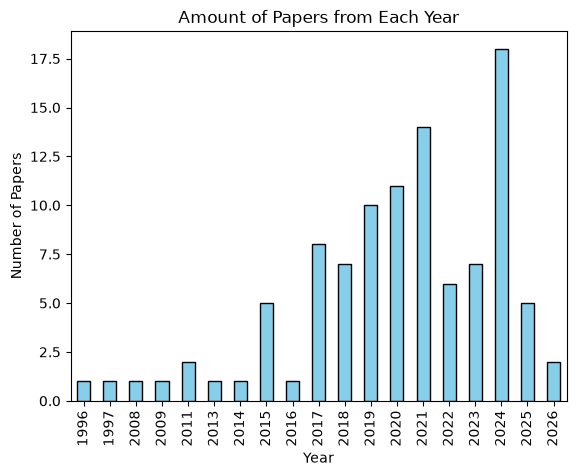

In [33]:
year_freq = df["Year"].value_counts().sort_index()

year_freq.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Amount of Papers from Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.show()